#Loan Approval Prediction

###Objective:
To predict whether a loan will be approved or not based on applicant details
such as income, education, credit history, and property area.

###Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/LoanApprovalPrediction gfg.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


###Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [4]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


* In this dataset their are three column with null values.

In [5]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [6]:
df.describe(include='object')

,Loan_ID,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
count,598,598,598,598,598,598,598
unique,598,2,2,2,2,3,2
top,LP002990,Male,Yes,Graduate,No,Semiurban,Y
freq,1,487,388,465,488,225,411


In [7]:
if 'Loan_Status' in df.columns:
  print('\nTarget Distribution: ')
  check=df['Loan_Status'].value_counts(normalize=True)*100
  print(check.round(2))


Target Distribution: 
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


###Handling Missing Value

In [8]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

* Filled missing values with the most frequent category since Dependents is a categorical/discrete feature.
* Used median because loan amounts are numerical and median is robust to outliers/skewed values.
* Replaced NaNs with the most common loan term since this feature has standard repeated durations.
* Used mode because credit history is a binary/categorical feature, so the most frequent class is the safest fill.

In [9]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [10]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

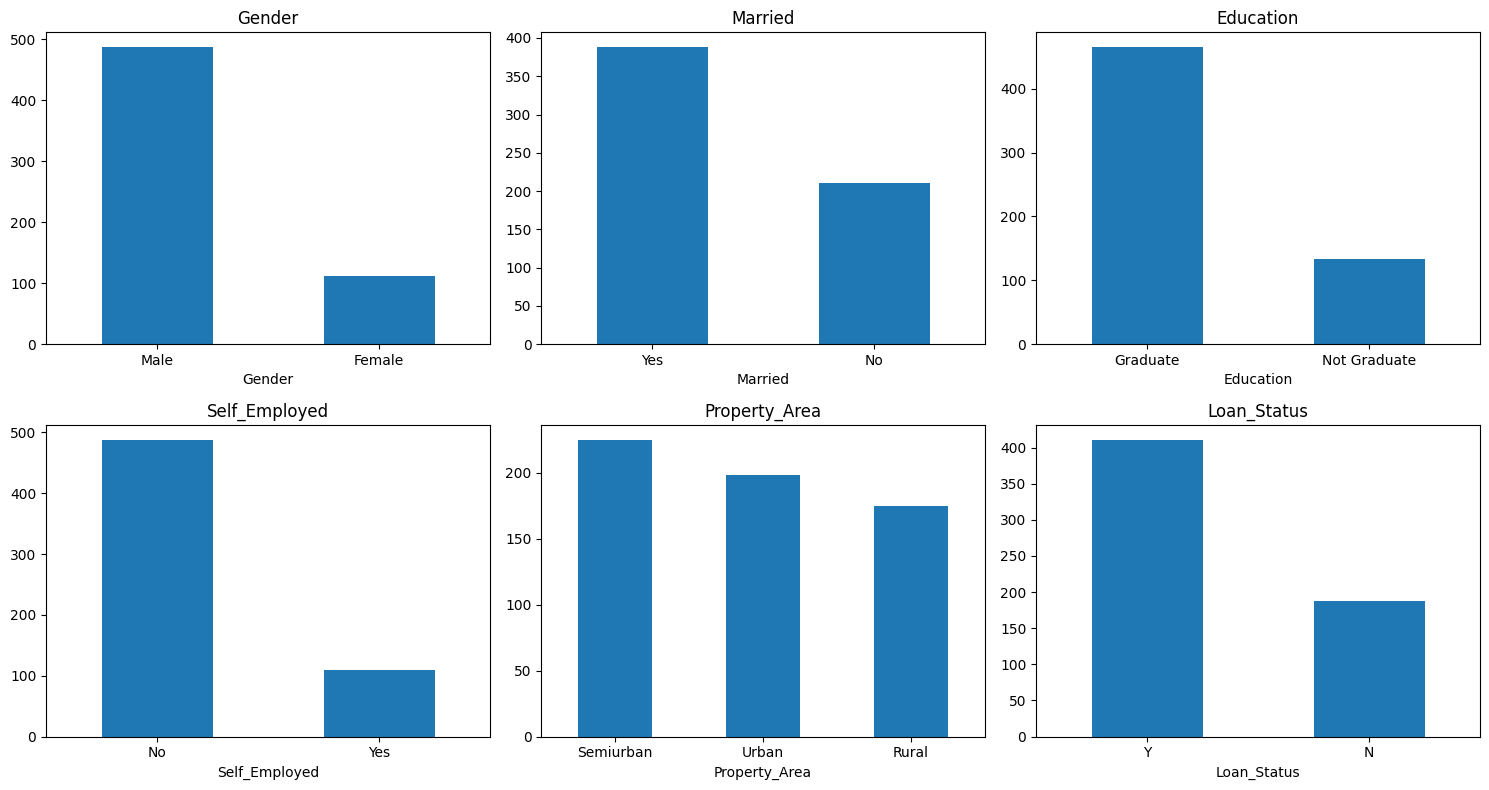

In [11]:
obj=df.select_dtypes(include='object').drop(columns=['Loan_ID'])
obj_cols=list(obj)
obj_len=len(obj_cols)
plt.figure(figsize=(15,8))
for i, col in enumerate(obj_cols, start=1):
  plt.subplot(2,obj_len//2, i)
  df[col].value_counts().plot(kind='bar')
  plt.title(col)
  plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* Gender: Majority of applicants are male, indicating a gender imbalance in loan applications.
* Married: Most applicants are married, suggesting married individuals apply more frequently for loans.
* Education: Graduates form the majority of applicants, showing higher loan application rates among educated individuals.
* Self_Employed: Most applicants are not self-employed, indicating salaried individuals dominate the dataset.
* Property_Area: Semiurban areas have the highest number of applicants compared to urban and rural areas.
* Loan_Status: Loan approvals (Y) are significantly higher than rejections (N).

In [12]:
from sklearn.preprocessing import LabelEncoder
df1=df.copy().drop(columns=['Loan_ID'])
le=LabelEncoder()
obj=df1.select_dtypes(include='object')
for col in obj.columns:
  df1[col]=le.fit_transform(df1[col])

* Categorical variables were converted into numerical form using encoding
because machine learning models work only with numerical data.


##Understanding dataset through Visualizing

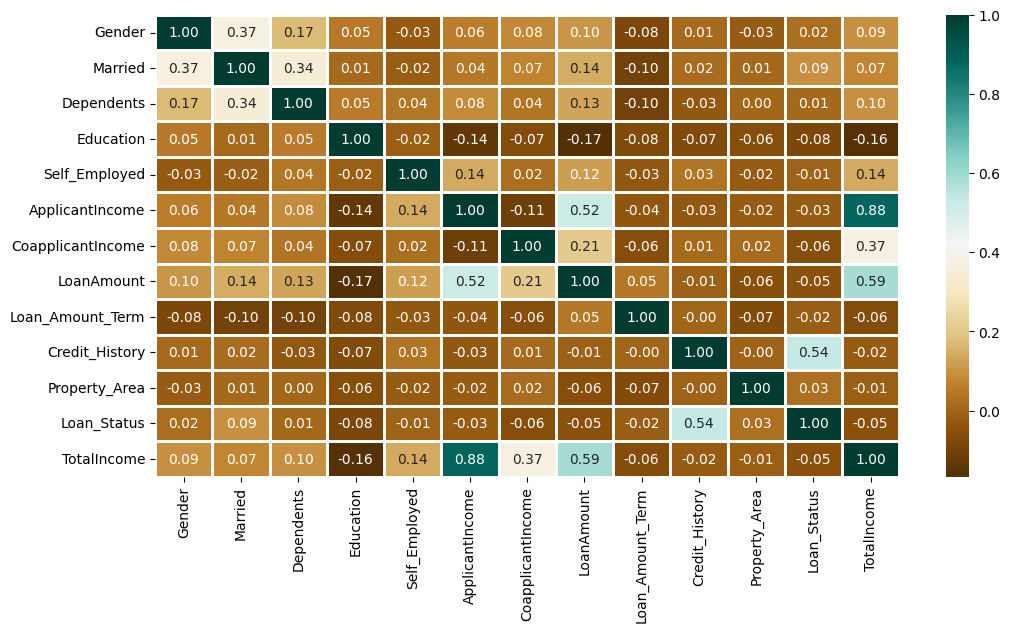

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(df1.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
plt.show()

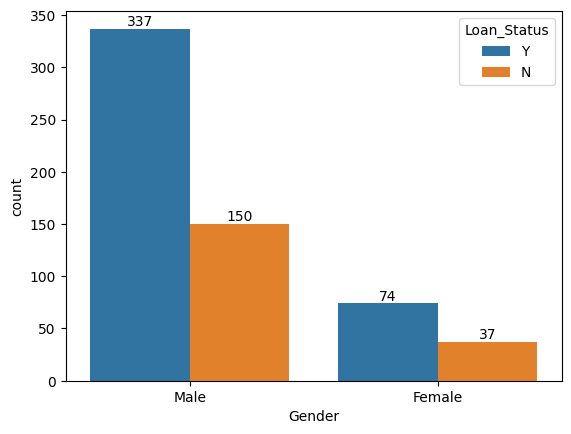

In [53]:
ax=sns.countplot(x=df['Gender'],  hue=df['Loan_Status'])
for cnt in ax.containers:
  ax.bar_label(cnt)
plt.show()

* Gender vs Loan Status: Male applicants received more loan approvals and rejections than female applicants, reflecting their higher representation in the dataset.

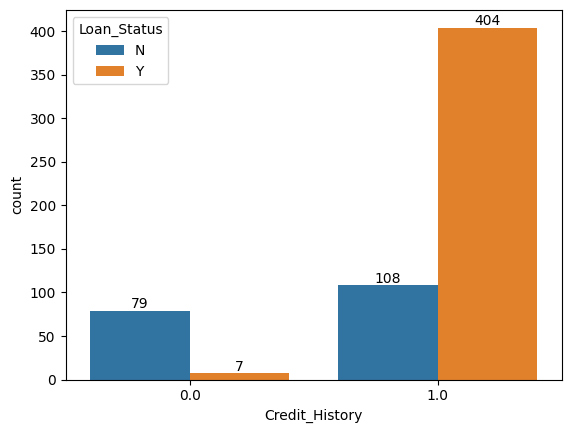

In [56]:
ax=sns.countplot(x=df['Credit_History'], hue=df['Loan_Status'])
for cnt in ax.containers:
  ax.bar_label(cnt)
plt.show()

* Credit History vs Loan Status: Applicants with a good credit history (1.0) had significantly higher loan approval rates, while most applicants with poor credit history (0.0) were rejected.

###Spliting Data for training & testing

In [16]:
from sklearn.model_selection import train_test_split
x=df1.drop(['Loan_Status'], axis=1)
y=df1['Loan_Status']
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.4, stratify=y, random_state=42)
print(f'train size: {x_train.shape[0]}, test size: {x_test.shape[0]}')

train size: 358, test size: 240


* The dataset was split into training and testing sets to evaluate
model performance on unseen data.


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models= {
    'KNN':Pipeline([('scaler', StandardScaler()), ('knn',KNeighborsClassifier(n_neighbors=3))]),
    'RF':RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', criterion='entropy', random_state=42),
    'DTC': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'SVC': Pipeline([('scaler', StandardScaler()), ('svc',SVC(class_weight='balanced'))]),
    'LogReg': Pipeline([('scaler', StandardScaler()), ('lc',LogisticRegression(max_iter=100, class_weight='balanced'))])
}

for name, clf in models.items():
  clf.fit(x_train, y_train)
  y_pred=clf.predict(x_test)
  print(f'Accuracy score of {name} = {100*accuracy_score(y_test, y_pred):.2f}')
  print(f'confusion matrix = \n{confusion_matrix(y_test, y_pred)}')
  #print(f'classification report = \n{classification_report(y_test, y_pred)}')

Accuracy score of KNN = 75.83
confusion matrix = 
[[ 32  43]
 [ 15 150]]
Accuracy score of RF = 80.83
confusion matrix = 
[[ 36  39]
 [  7 158]]
Accuracy score of DTC = 74.58
confusion matrix = 
[[ 41  34]
 [ 27 138]]
Accuracy score of SVC = 78.75
confusion matrix = 
[[ 37  38]
 [ 13 152]]
Accuracy score of LogReg = 76.25
confusion matrix = 
[[ 34  41]
 [ 16 149]]


* Implemented multiple machine learning classification models (KNN, Random Forest, Decision Tree, SVM, and Logistic Regression) to predict loan approval status.
* Used Pipeline with StandardScaler for KNN, SVM, and Logistic Regression to normalize feature values before training.
* Applied class_weight='balanced' in selected models to handle class imbalance in the dataset.
* Trained each model on the training dataset and generated predictions on the test dataset.
* Evaluated model performance using accuracy score and confusion matrix for comparison.

##Conclusion
* Credit History is the most important factor in loan approval
* Feature engineering improved prediction accuracy
* Although multiple models were evaluated, Random Forest was selected
as the final model because it produced the lowest number of false
negatives, which is critical in loan approval systems to avoid
rejecting eligible customers.